# Linear-Quadratic Benchmark

This notebook imports saved LQ runs from `results/lq`. It is analysis-only and does not run training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    gradient_diagnostics,
    load_runs,
    objective_table,
    plot_flow_comparison,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
    transport_correction_table,
)

ENV = 'lq'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 55 saved runs from /home/adonis/Internship/mfc/results/lq


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. Exact-flow and particle-flow transport runs are shown separately.

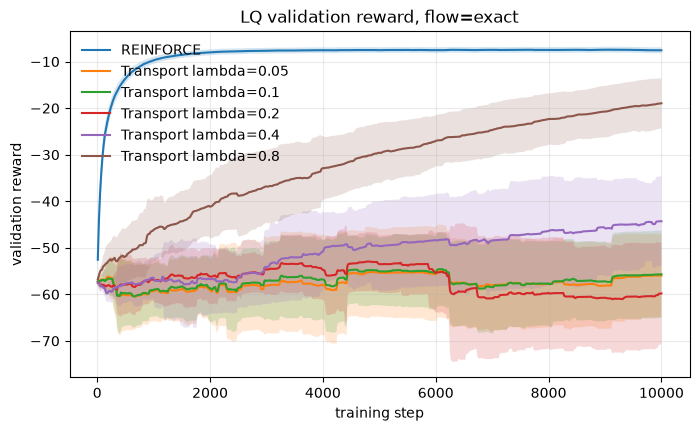

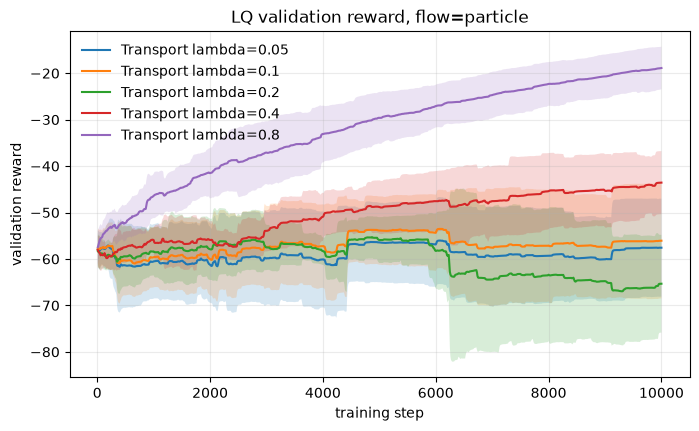

In [ ]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    for flow in sorted({run['metadata']['flow'] for run in runs}):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        try:
            plot_validation_rewards(runs, env=ENV, horizon=20, flow=flow, ax=ax)
            ax.set_title(f'LQ validation reward, flow={flow}')
            plt.show()
        except ValueError as exc:
            plt.close(fig)
            print(exc)

## Mean and Variance Flow

Population mean and variance induced by the best saved policy for each algorithm, perturbation, and flow setting.

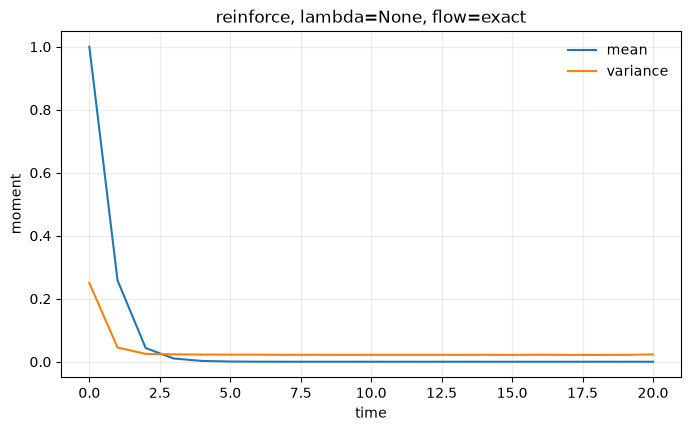

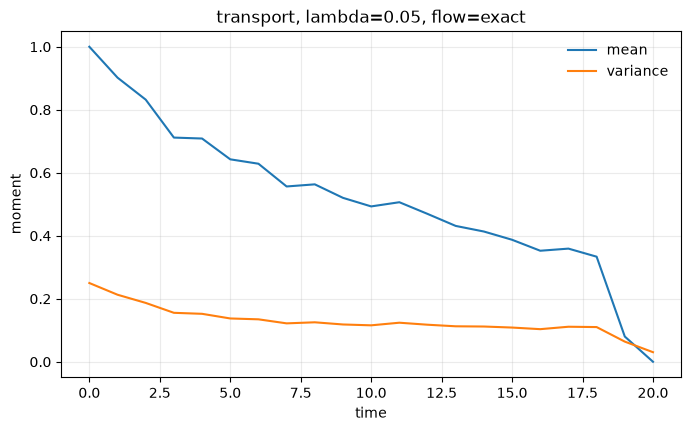

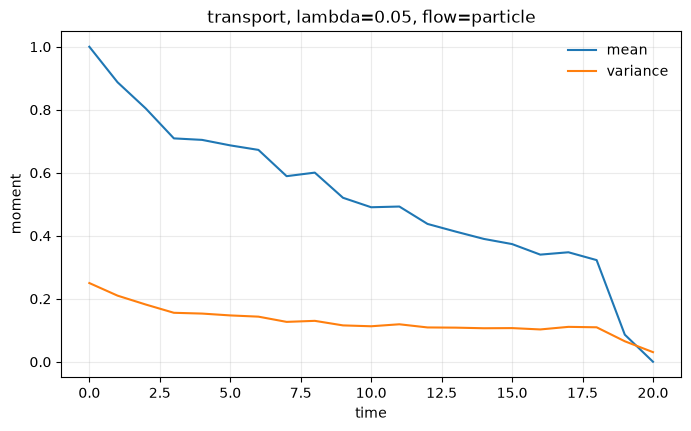

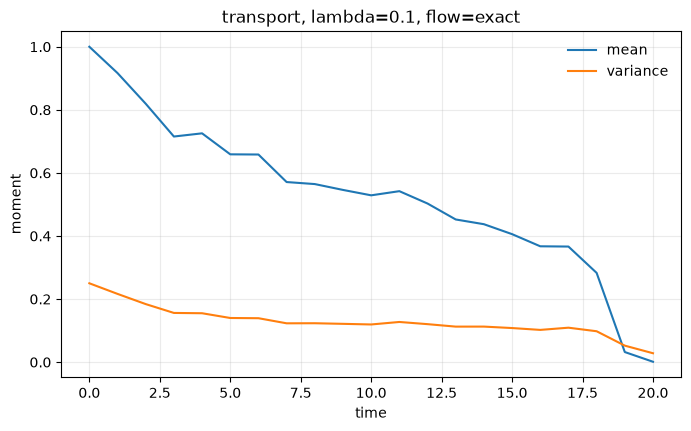

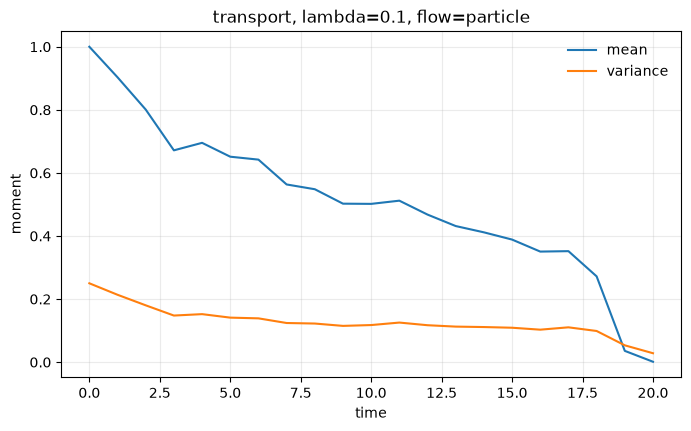

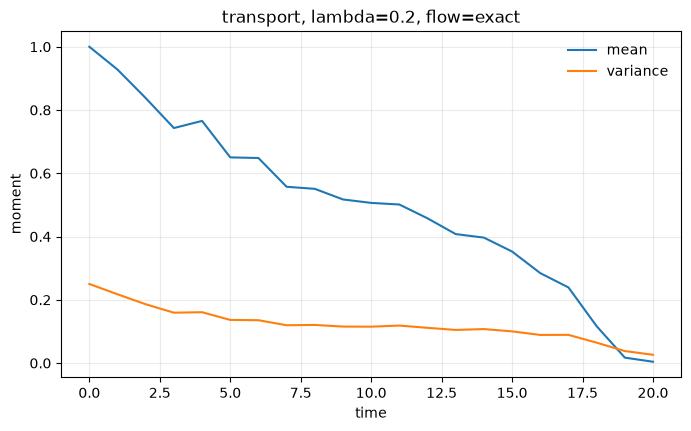

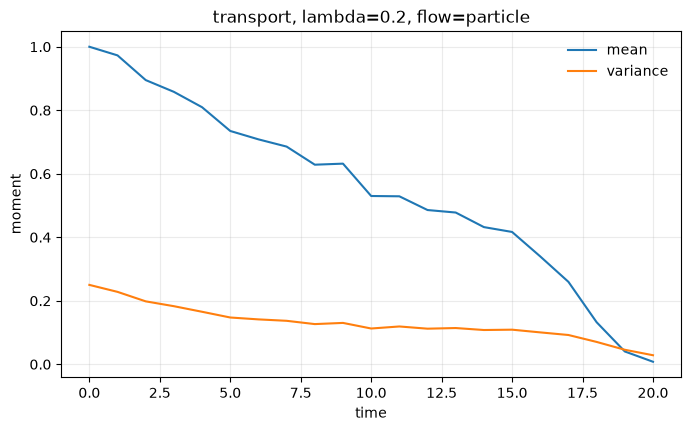

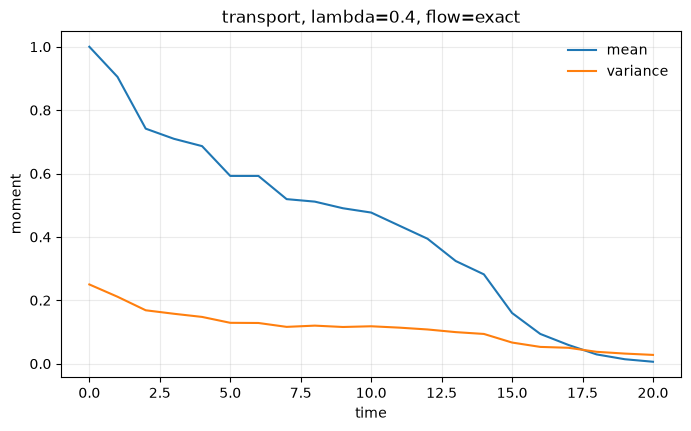

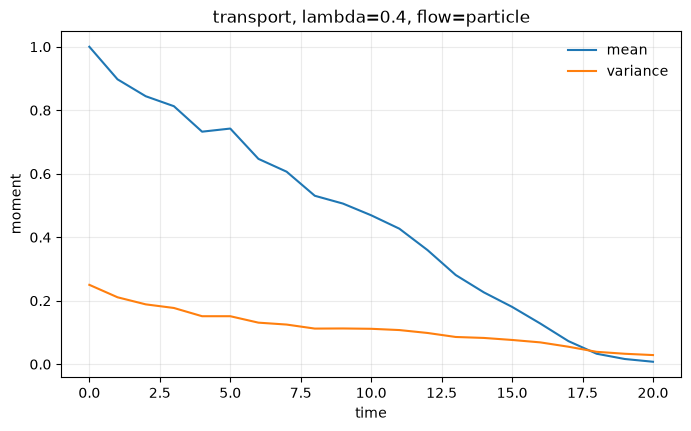

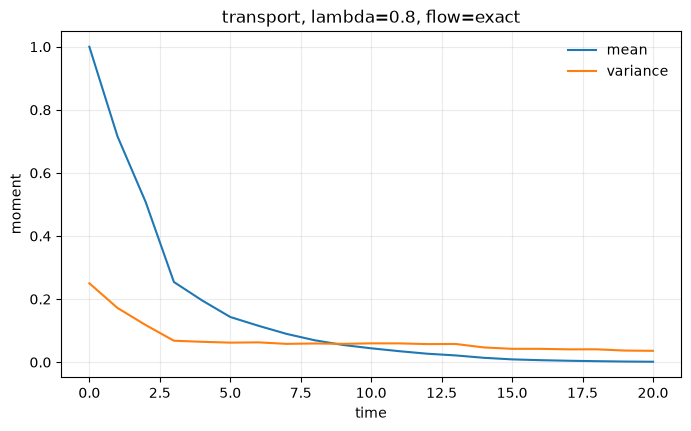

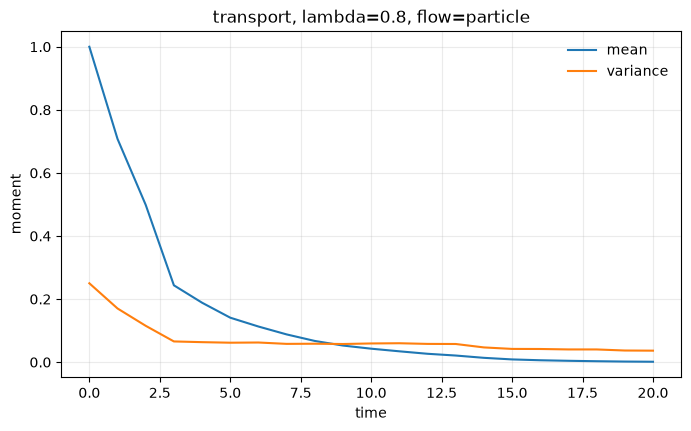

In [3]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, lambda={meta['perturbation']}, flow={meta['flow']}")
    plt.show()

## Exact vs Particle Flow

Transport validation curves split by exact and particle flow. This is the main comparison for whether estimating the population flow changes training behavior.

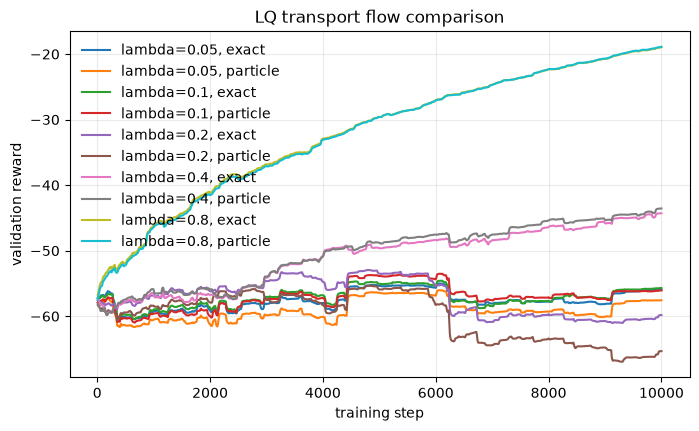

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
try:
    plot_flow_comparison(runs, env=ENV, horizon=20, ax=ax)
    ax.set_title('LQ transport flow comparison')
    plt.show()
except ValueError as exc:
    plt.close(fig)
    print(exc)

## Objective Table: J vs J^lambda

Closed-form objective values at the learned policy. `J0_star` is included when the environment exposes the analytical optimizer.

In [5]:
display(objective_table(runs))

,env,label,flow,horizon,seed,validation_reward,objective_convention,J0,J0_star,Jlambda,Jlambda_star
0,lq,REINFORCE,exact,20,0,-8.425707,cost,7.517084,7.223777,NaN,NaN
1,lq,REINFORCE,exact,20,1,-7.570883,cost,7.516312,7.223777,NaN,NaN
2,lq,REINFORCE,exact,20,2,-6.716252,cost,7.515778,7.223777,NaN,NaN
3,lq,REINFORCE,exact,20,3,-7.876723,cost,7.515043,7.223777,NaN,NaN
4,lq,REINFORCE,exact,20,4,-7.262981,cost,7.514515,7.223777,NaN,NaN
5,lq,Transport lambda=0.05,exact,20,0,-67.788292,cost,67.417237,7.223777,67.815968,7.499206
6,lq,Transport lambda=0.05,exact,20,1,-53.078082,cost,53.199619,7.223777,53.568841,7.499206
7,lq,Transport lambda=0.05,exact,20,2,-58.362791,cost,58.921473,7.223777,59.302641,7.499206
8,lq,Transport lambda=0.05,exact,20,3,-57.376739,cost,56.511912,7.223777,56.888498,7.499206
9,lq,Transport lambda=0.05,exact,20,4,-43.246380,cost,43.737745,7.223777,44.087483,7.499206


## Transport Gradient Diagnostics

Optional Monte Carlo check of bias, MSE, cosine similarity, and perturbation bias against the exact LQ gradient oracle. Leave disabled for ordinary report viewing.

In [9]:
RUN_GRADIENT_DIAGNOSTICS = True
N_REPLICATIONS = 20

if RUN_GRADIENT_DIAGNOSTICS:
    tables = []
    for run in runs:
        try:
            tables.append(gradient_diagnostics(run, n_replications=N_REPLICATIONS))
        except ValueError:
            pass
    display(pd.concat(tables, ignore_index=True) if tables else pd.DataFrame())
else:
    print('Set RUN_GRADIENT_DIAGNOSTICS = True to recompute gradient bias/MSE diagnostics.')

,env,label,flow,horizon,lambda,n_parameters,diagnostic_n_particles,n_replications,bias_norm,estimate_std,...,bias_z,bias_z_null_rms,bias_chi2_stat,bias_chi2_df,bias_chi2_pvalue,mse,cosine_similarity,exact_gradient_norm,estimate_gradient_norm_mean,perturbation_bias_norm
0,lq,Transport lambda=0.05,exact,20,0.05,40,220,20,2.363432e+16,1.105125e+17,...,0.956416,1.0,36.589258,40,0.624598,3.040234e+32,0.436154,179.178434,2.722324e+16,0.372903
1,lq,Transport lambda=0.05,exact,20,0.05,40,220,20,9.538387e+14,7.733179e+15,...,0.551610,1.0,12.170931,40,0.999994,1.443044e+30,0.347216,134.715939,2.357876e+15,0.279520
2,lq,Transport lambda=0.05,exact,20,0.05,40,220,20,9.461962e+16,4.242937e+17,...,0.997309,1.0,39.784989,40,0.479832,4.499418e+33,0.479193,164.577153,9.543235e+16,0.342057
3,lq,Transport lambda=0.05,exact,20,0.05,40,220,20,1.205460e+16,5.359660e+16,...,1.005844,1.0,40.468850,40,0.449563,7.185698e+31,0.461020,161.397091,1.216472e+16,0.335569
4,lq,Transport lambda=0.05,exact,20,0.05,40,220,20,2.607455e+15,1.157784e+16,...,1.007174,1.0,40.575946,40,0.444875,3.353570e+30,-0.492256,108.603278,2.624685e+15,0.224693
5,lq,Transport lambda=0.05,particle,20,0.05,40,220,20,8.753189e+15,3.166602e+16,...,1.236197,1.0,61.127339,40,0.017325,2.573046e+31,-0.468307,172.194975,9.577448e+15,0.358162
6,lq,Transport lambda=0.05,particle,20,0.05,40,220,20,2.162221e+14,2.825626e+15,...,0.342216,1.0,4.684472,40,1.000000,1.907927e+29,-0.034126,124.476725,9.082334e+14,0.258058
7,lq,Transport lambda=0.05,particle,20,0.05,40,220,20,2.624735e+16,1.199229e+17,...,0.978810,1.0,38.322759,40,0.545905,3.587836e+32,-0.458331,185.946909,2.751111e+16,0.386945
8,lq,Transport lambda=0.05,particle,20,0.05,40,220,20,1.617213e+16,7.220289e+16,...,1.001677,1.0,40.134261,40,0.464304,1.303533e+32,-0.450661,167.750625,1.647648e+16,0.348985
9,lq,Transport lambda=0.05,particle,20,0.05,40,220,20,3.138005e+14,1.053501e+15,...,1.332090,1.0,70.978575,40,0.001831,2.882104e+28,0.530182,108.751479,3.259369e+14,0.224943


## Missing Mean-Field Correction Term

Optional diagnostic comparing the full transport gradient with the policy-only term. The difference is the mean-field correction that classical REINFORCE drops.

In [10]:
RUN_CORRECTION_DIAGNOSTIC = True

if RUN_CORRECTION_DIAGNOSTIC:
    tables = []
    for run in runs:
        try:
            tables.append(transport_correction_table(run, n_replications=N_REPLICATIONS))
        except ValueError:
            pass
    display(pd.concat(tables, ignore_index=True) if tables else pd.DataFrame())
else:
    print('Set RUN_CORRECTION_DIAGNOSTIC = True to estimate the missing correction term.')

KeyboardInterrupt: 

## Runtime Table

Average elapsed time and estimated simulator budget for each algorithm configuration.

In [ ]:
display(runtime_table(runs))

,env,algorithm,perturbation,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,lq,reinforce,NaN,20,exact,6.751940,0.232560,87.511611,0.556441,6.027560,0.030104,100.320626,0.588966,0.008751,0.010032,0.006028,4420.0,5
1,lq,transport,0.05,20,exact,6.992508,0.475617,880.236145,3.569792,4.681338,0.016061,891.945447,3.405419,0.088024,0.089195,0.004681,4420.0,5
2,lq,transport,0.05,20,particle,8.853466,1.484421,901.131143,3.576476,6.361999,0.063560,916.382099,4.643821,0.090113,0.091638,0.006362,8420.0,5
3,lq,transport,0.10,20,exact,6.621492,0.117705,882.943192,5.609188,4.713309,0.051378,894.313598,5.579607,0.088294,0.089431,0.004713,4420.0,5
4,lq,transport,0.10,20,particle,8.273656,1.509516,902.143514,4.997738,6.346589,0.041255,916.800958,4.461218,0.090214,0.091680,0.006347,8420.0,5
5,lq,transport,0.20,20,exact,8.094328,1.272730,883.319109,9.641389,4.707855,0.053816,896.157302,10.850240,0.088332,0.089616,0.004708,4420.0,5
6,lq,transport,0.20,20,particle,6.651145,0.291306,904.883635,5.241202,6.382060,0.037157,917.952634,5.401157,0.090488,0.091795,0.006382,8420.0,5
7,lq,transport,0.40,20,exact,8.125355,1.525226,881.536087,7.709523,4.669695,0.043572,894.367533,8.469426,0.088154,0.089437,0.004670,4420.0,5
8,lq,transport,0.40,20,particle,8.716017,1.271594,899.751035,4.246783,6.325444,0.031290,914.829884,4.628917,0.089975,0.091483,0.006325,8420.0,5
9,lq,transport,0.80,20,exact,7.257255,0.107670,882.731899,5.853065,4.711517,0.035363,894.735714,5.869911,0.088273,0.089474,0.004712,4420.0,5
